# Regression and Classification Evaluation Metrics

## Task 1: Data Preparation

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Feature names:", data.feature_names)
print("Target names:", data.target_names)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']
Shape of X: (569, 30)
Shape of y: (569,)


In [3]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
print("Dataset shape:", df.shape)
print("\nColumn info:")
df.info()

print("\nStatistical summary:")
df.describe()

Dataset shape: (569, 31)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


Target distribution:
target
1    357
0    212
Name: count, dtype: int64

0 = Malignant, 1 = Benign


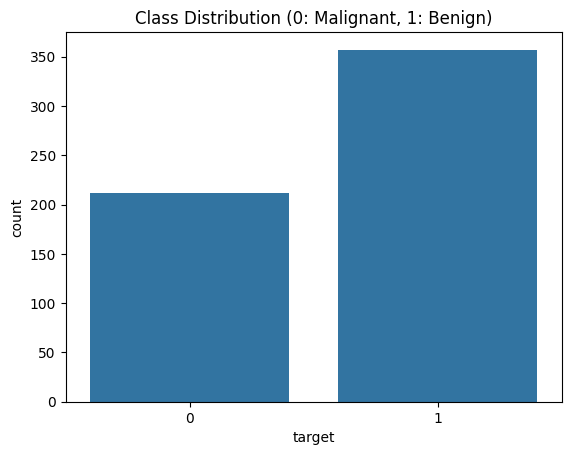

In [5]:
print("Target distribution:")
print(df['target'].value_counts())
print("\n0 = Malignant, 1 = Benign")

sns.countplot(x='target', data=df)
plt.title("Class Distribution (0: Malignant, 1: Benign)")
plt.show()

In [ ]:
print("Missing values per column:\n", df.isnull().sum().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values per column:
 0

Number of duplicate rows: 0


In [7]:
X = df.drop('target', axis=1)
y = df['target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


### Why Feature Scaling is Important Here

KNN is a distance-based algorithm. Features in this  dataset are on very different scales for example, mean area can be in the hundreds/thousands, while mean smoothness is a small decimal (0–1 range).

Without scaling, features with larger numeric ranges (like area or perimeter) would  dominate the distance calculation, effectively drowning out the contribution of  smaller-scale features (like smoothness or symmetry), even if they are equally or more predictive.

StandardScaler transforms each feature to have mean = 0 and standard deviation = 1, ensuring all 30 features contribute proportionally to the distance metric used by KNN. This typically improves both accuracy and convergence stability for distance-based models.

## Task 2: Train-Test Split Analysis

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_scaled_arr = X_scaled
y_arr = y.values

splits = {
    "80:20": 0.20,
    "70:30": 0.30,
    "90:10": 0.10
}

split_results = {}
for name, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled_arr, y_arr, test_size=test_size, random_state=42, stratify=y_arr
    )
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    split_results[name] = {
        "train_size": X_train.shape[0],
        "test_size": X_test.shape[0],
        "accuracy": acc
    }

results_df = pd.DataFrame(split_results).T
results_df

,train_size,test_size,accuracy
80:20,455.0,114.0,0.964912
70:30,398.0,171.0,0.970760
90:10,512.0,57.0,0.982456


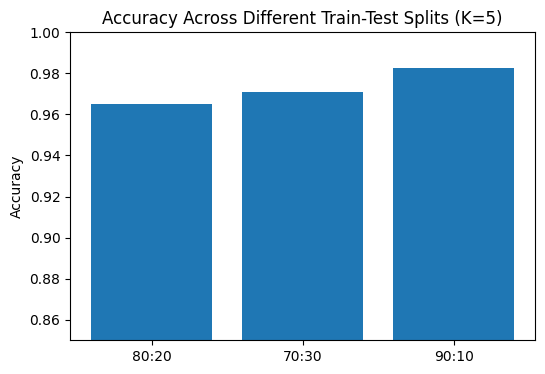

In [9]:
plt.figure(figsize=(6,4))
plt.bar(results_df.index, results_df['accuracy'])
plt.ylim(0.85, 1.0)
plt.ylabel("Accuracy")
plt.title("Accuracy Across Different Train-Test Splits (K=5)")
plt.show()

### Analysis: Effect of Splitting on Stability and Generalization

- **90:10 split**: More training data - the model sees more patterns, but the small test set (only ~57 samples) means accuracy estimates have higher variance and are less reliable as a generalization measure.
- **70:30 split**: Less training data - the model may underfit slightly since it has fewer examples to learn from, but the larger test set gives a more statistically stable accuracy estimate.
- **80:20 split**: A common middle ground — balances having enough training data with a test set large enough to reliably estimate generalization performance.

## Task 3: KNN Model with Heuristic K Selection

In [10]:
import math
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_arr, y_arr, test_size=0.20, random_state=42, stratify=y_arr
)

n_train = X_train.shape[0]
k_heuristic = round(math.sqrt(n_train))

if k_heuristic % 2 == 0:
    k_heuristic += 1

print(f"Number of training samples: {n_train}")
print(f"Heuristic K (sqrt(n)): {k_heuristic}")

Number of training samples: 455
Heuristic K (sqrt(n)): 21


In [11]:
k_range = range(max(1, k_heuristic - 5), k_heuristic + 6)

accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

k_results_df = pd.DataFrame({"K": list(k_range), "Accuracy": accuracies})
k_results_df

,K,Accuracy
0,16,0.973684
1,17,0.973684
2,18,0.982456
3,19,0.973684
4,20,0.964912
5,21,0.956140
6,22,0.956140
7,23,0.964912
8,24,0.956140
9,25,0.964912


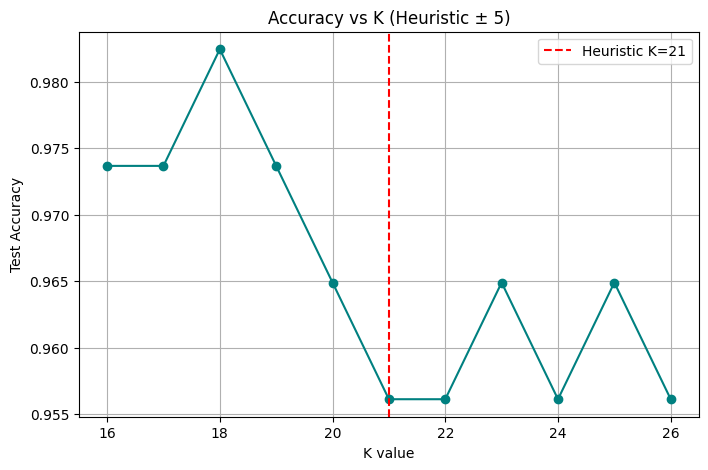

Best K in this range: 18, Accuracy: 0.9825


In [12]:
plt.figure(figsize=(8,5))
plt.plot(k_results_df["K"], k_results_df["Accuracy"], marker='o', color='teal')
plt.axvline(x=k_heuristic, color='red', linestyle='--', label=f'Heuristic K={k_heuristic}')
plt.xlabel("K value")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs K (Heuristic ± 5)")
plt.legend()
plt.grid(True)
plt.show()

best_k_row = k_results_df.loc[k_results_df["Accuracy"].idxmax()]
print(f"Best K in this range: {int(best_k_row['K'])}, Accuracy: {best_k_row['Accuracy']:.4f}")

### Identifying Optimal K

Looking at the accuracy vs K plot: very small K (like 1-3) tends to overfit the model is sensitive to noise and individual outlier points. As K increases moderately, accuracy typically stabilizes or improves slightly since the model averages over more neighbors, smoothing out noise. If K becomes too large, accuracy may start to drop again as the model oversmooths and starts ignoring local structure, biasing toward the majority class. The optimal K is where accuracy peaks or plateaus before this decline identified above from the plot.

### Distance Metrics in KNN

**1. Euclidean Distance**
Formula: d(x, y) = sqrt(Σ(xᵢ - yᵢ)²)

This is the straight-line distance between two points in 
feature space. It's the default and most commonly used metric in KNN.

**When suitable**: Works best when features are continuous, roughly on the same 
scale (hence why we scaled our data), and when the relationship between features 
is expected to be similar in all directions (isotropic space). It's a good default 
for datasets like this one with real-valued measurements (radius, area, smoothness, etc).

**2. Manhattan Distance**
Formula: d(x, y) = Σ|xᵢ - yᵢ|

Also called "city block" distance — it sums the absolute differences along each 
dimension, like navigating a grid of city blocks rather than cutting diagonally.

**When suitable**: Works well in high-dimensional spaces where Euclidean distance 
can become less meaningful, and when data has 
many outliers, since Manhattan distance is less sensitive to large deviations 
in a single feature compared to Euclidean distance (which squares differences).

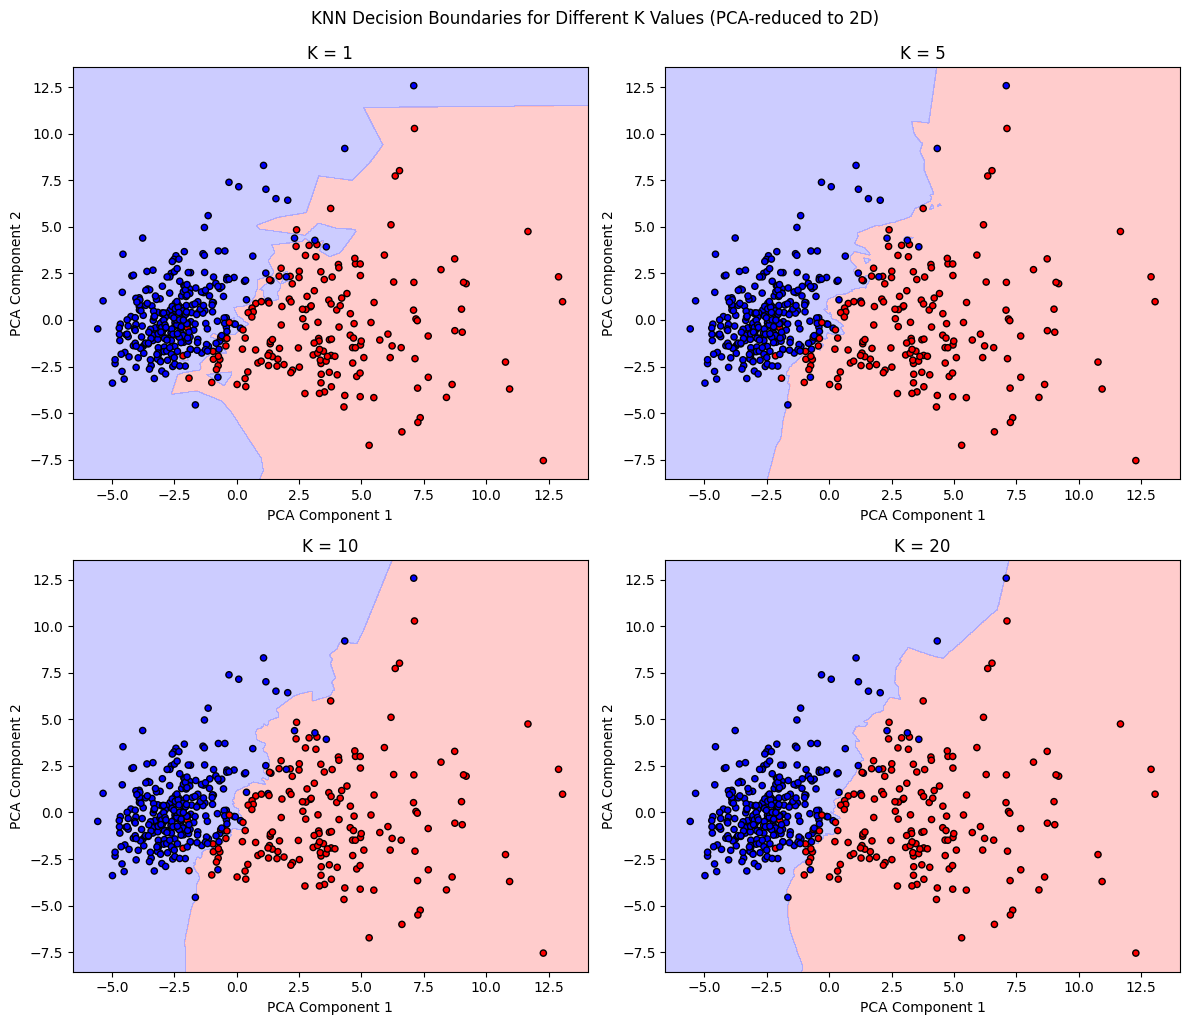

In [13]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_arr)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y_arr, test_size=0.20, random_state=42, stratify=y_arr
)

def plot_decision_boundary(X, y, k, ax):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)
    
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])
    
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    ax.set_title(f"K = {k}")
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")

k_values = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, k in enumerate(k_values):
    plot_decision_boundary(X_train_pca, y_train_pca, k, axes[i])

plt.tight_layout()
plt.suptitle("KNN Decision Boundaries for Different K Values (PCA-reduced to 2D)", y=1.02)
plt.show()

### Analysis: Decision Boundary vs K

- **K = 1**: Highly irregular, jagged boundary that tightly follows individual 
  training points. This is a classic sign of overfitting, as the model memorizes 
  noise and outliers rather than learning the general trend.
- **K = 5**: Boundary becomes noticeably smoother, capturing the general class 
  separation while still adapting reasonably to local structure.
- **K = 10**: Even smoother boundary, the model is now averaging over more 
  neighbors, making it more robust to noise but slightly less sensitive to 
  fine-grained local patterns.
- **K = 20**: The boundary becomes very smooth, nearly linear in some regions,
  at this point, the model may start to underfit, since it's overly influenced 
  by the global class distribution rather than local neighborhoods.

**Trend**: As K increases, the decision boundary transitions from complex/overfit 
to smooth/potentially underfit. This illustrates the classic bias-variance tradeoff 
in KNN: low K = low bias/high variance, high K = high bias/low variance.

## Task 4: Cross Validation

In [14]:
from sklearn.model_selection import cross_val_score, KFold

k_range_cv = range(1, 31)
cv_5_means = []
cv_10_means = []

for k in k_range_cv:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    scores_5 = cross_val_score(knn, X_scaled_arr, y_arr, cv=5, scoring='accuracy')
    scores_10 = cross_val_score(knn, X_scaled_arr, y_arr, cv=10, scoring='accuracy')
    
    cv_5_means.append(scores_5.mean())
    cv_10_means.append(scores_10.mean())

cv_results_df = pd.DataFrame({
    "K": list(k_range_cv),
    "CV_5_Accuracy": cv_5_means,
    "CV_10_Accuracy": cv_10_means
})
cv_results_df.head(10)

,K,CV_5_Accuracy,CV_10_Accuracy
0,1,0.950769,0.950752
1,2,0.941919,0.945457
2,3,0.957771,0.964787
3,4,0.961279,0.966541
4,5,0.964850,0.966635
5,6,0.963080,0.961310
6,7,0.968359,0.968390
7,8,0.968343,0.964818
8,9,0.968390,0.964850
9,10,0.964866,0.970113


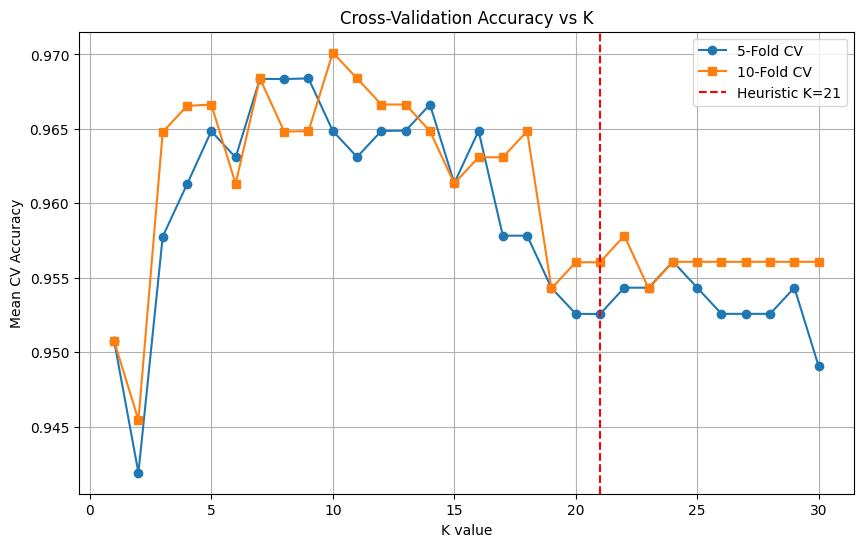

Best K (5-Fold CV): 9, Accuracy: 0.9684
Best K (10-Fold CV): 10, Accuracy: 0.9701


In [15]:
plt.figure(figsize=(10,6))
plt.plot(cv_results_df["K"], cv_results_df["CV_5_Accuracy"], marker='o', label="5-Fold CV")
plt.plot(cv_results_df["K"], cv_results_df["CV_10_Accuracy"], marker='s', label="10-Fold CV")
plt.axvline(x=k_heuristic, color='red', linestyle='--', label=f'Heuristic K={k_heuristic}')
plt.xlabel("K value")
plt.ylabel("Mean CV Accuracy")
plt.title("Cross-Validation Accuracy vs K")
plt.legend()
plt.grid(True)
plt.show()

best_k_cv5 = cv_results_df.loc[cv_results_df["CV_5_Accuracy"].idxmax()]
best_k_cv10 = cv_results_df.loc[cv_results_df["CV_10_Accuracy"].idxmax()]

print(f"Best K (5-Fold CV): {int(best_k_cv5['K'])}, Accuracy: {best_k_cv5['CV_5_Accuracy']:.4f}")
print(f"Best K (10-Fold CV): {int(best_k_cv10['K'])}, Accuracy: {best_k_cv10['CV_10_Accuracy']:.4f}")

In [16]:
comparison_df = pd.DataFrame({
    "Method": ["80:20 Split (K=5)", "5-Fold CV (best K)", "10-Fold CV (best K)"],
    "K": [5, int(best_k_cv5['K']), int(best_k_cv10['K'])],
    "Accuracy": [
        results_df.loc["80:20", "accuracy"],
        best_k_cv5['CV_5_Accuracy'],
        best_k_cv10['CV_10_Accuracy']
    ]
})
comparison_df

,Method,K,Accuracy
0,80:20 Split (K=5),5,0.964912
1,5-Fold CV (best K),9,0.968390
2,10-Fold CV (best K),10,0.970113


Choose the K that performs best under cross-validation (5-fold or 10-fold), using the heuristic K as a sanity-check reference point. If the CV-optimal K is close to the heuristic K, that gives extra confidence in the choice; if it differs significantly, trust the CV result since it's based on more robust evidence.

## Task 5: Classification Evaluation

In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, RocCurveDisplay
)

final_k = int(best_k_cv10['K'])

knn_final = KNeighborsClassifier(n_neighbors=final_k)
knn_final.fit(X_train, y_train)

y_pred_final = knn_final.predict(X_test)
y_prob_final = knn_final.predict_proba(X_test)[:, 1]

print(f"Final Model: K = {final_k}")

Final Model: K = 10


In [18]:
acc = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final)
rec = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.9737
Precision: 0.9726
Recall:    0.9861
F1 Score:  0.9793


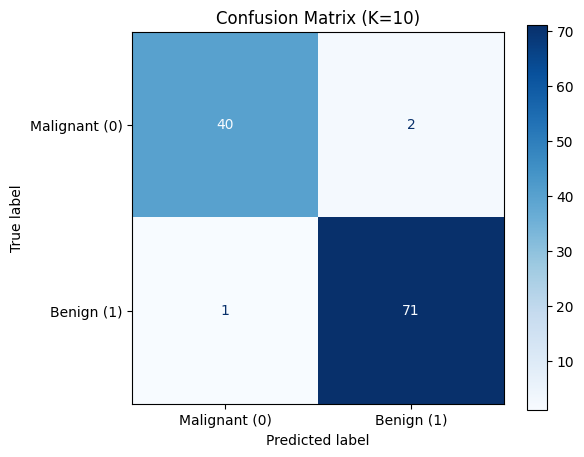

True Negatives (correctly Malignant): 40
False Positives (Malignant predicted as Benign): 2
False Negatives (Benign predicted as Malignant): 1
True Positives (correctly Benign): 71


In [19]:
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant (0)", "Benign (1)"])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix (K={final_k})")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly Malignant): {tn}")
print(f"False Positives (Malignant predicted as Benign): {fp}")
print(f"False Negatives (Benign predicted as Malignant): {fn}")
print(f"True Positives (correctly Benign): {tp}")

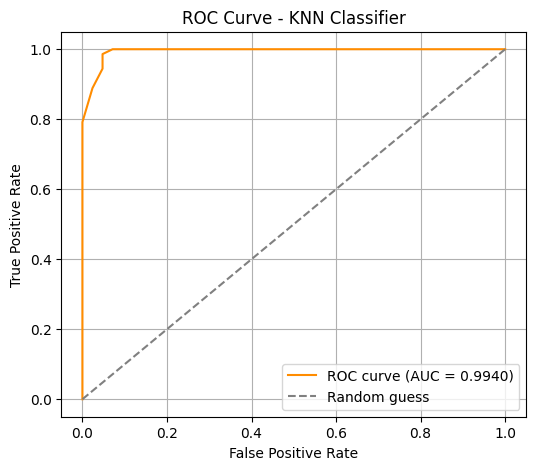

AUC Score: 0.9940


In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
auc_score = roc_auc_score(y_test, y_prob_final)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC Score: {auc_score:.4f}")

In [21]:
metrics_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"],
    "Value": [acc, prec, rec, f1, auc_score]
})
metrics_summary

,Metric,Value
0,Accuracy,0.973684
1,Precision,0.972603
2,Recall,0.986111
3,F1 Score,0.979310
4,AUC,0.994048


## Task 6: Comparative Study with Regression (Lab 3 Integration)

In [22]:
lab3_metrics = {
    "Attendance_to_GPA": {
        "Slope": 0.0196,
        "Intercept": 1.6286,
        "MSE": 0.0449,
        "RMSE": np.sqrt(0.0449),
        "R2": -0.4822,
        "MAE": None
    },
    "CIA_to_GPA": {
        "Slope": 0.0186,
        "Intercept": 2.1083,
        "MSE": 0.0221,
        "RMSE": np.sqrt(0.0221),
        "R2": 0.2697,
        "MAE": None
    }
}

lab3_df = pd.DataFrame(lab3_metrics).T
lab3_df

,Slope,Intercept,MSE,RMSE,R2,MAE
Attendance_to_GPA,0.0196,1.6286,0.0449,0.211896,-0.4822,NaN
CIA_to_GPA,0.0186,2.1083,0.0221,0.148661,0.2697,NaN


In [23]:
comparison_table = pd.DataFrame({
    "Aspect": ["Best-performing metric value", "R² / Accuracy", "RMSE / F1 Score", "Error type visibility"],
    "Regression - Attendance→GPA": [lab3_metrics["Attendance_to_GPA"]["MSE"], 
                                      lab3_metrics["Attendance_to_GPA"]["R2"], 
                                      round(lab3_metrics["Attendance_to_GPA"]["RMSE"], 4), 
                                      "MAE (magnitude only)"],
    "Regression - CIA→GPA": [lab3_metrics["CIA_to_GPA"]["MSE"], 
                              lab3_metrics["CIA_to_GPA"]["R2"], 
                              round(lab3_metrics["CIA_to_GPA"]["RMSE"], 4), 
                              "MAE (magnitude only)"],
    "Classification - KNN": [f"K={final_k}", round(acc, 4), round(f1, 4), "Confusion Matrix (type + direction)"]
})
comparison_table

,Aspect,Regression - Attendance→GPA,Regression - CIA→GPA,Classification - KNN
0,Best-performing metric value,0.0449,0.0221,K=10
1,R² / Accuracy,-0.4822,0.2697,0.9737
2,RMSE / F1 Score,0.2119,0.1487,0.9793
3,Error type visibility,MAE (magnitude only),MAE (magnitude only),Confusion Matrix (type + direction)


### Interpreting Lab 3 Numbers Alongside Lab 5

**R² Score comparison is the most revealing part here:**

- **Attendance → GPA: R² = -0.4822.** A negative R² means this model performs 
  *worse* than simply predicting the mean GPA for every student, attendance% 
  alone has essentially no useful linear relationship with GPA in your data, 
  and the fitted line actively hurts predictions compared to a flat baseline.
- **CIA → GPA: R² = 0.2697.** This model explains about 27% of the variance in 
  GPA : a weak-to-moderate relationship, but at least it beats the mean-baseline, 
  unlike the attendance model.


**RMSE vs F1 Score**: The CIA model's RMSE (~{{sqrt(0.0221) ≈ 0.1487}}) is in 
GPA units meaning predictions are off by about 0.15 GPA points on average 
(in a squared-then-rooted sense). This is directly interpretable on the GPA 
scale. F1 Score for the KNN model, by contrast, is unitless and only meaningful 
relative to the [0,1] range, it can't be compared numerically to RMSE, only 
conceptually (both summarize the balance/quality of predictions in one number).

**Takeaway**: Even though both labs use "evaluation metrics," the negative R² 
in the Attendance model versus the high accuracy in the KNN model reinforces 
why these are fundamentally different evaluation philosophies, regression 
punishes numerical distance from the true value (and can indicate a model is 
worse than a naive guess), while classification simply counts correct decisions 
without any notion of a "negative" score.

### Inference

- **Regression metrics (error magnitude):** MAE, MSE, RMSE measure how far predicted values deviate numerically from actual values smaller values mean predictions are numerically closer to the truth.

- **Classification metrics (decision correctness):** Accuracy, Precision, Recall, F1 measure whether predicted class labels match actual labels evaluated as counts of correct/incorrect decisions (TP/TN/FP/FN), not distance.

- **Accuracy insufficient in medical diagnosis:** With imbalanced classes, a model can score high accuracy by favoring the majority class while missing critical malignant cases , dangerous false negatives get hidden.

- **Recall & ROC-AUC more relevant in healthcare:** Recall minimizes missed malignant cases (false negatives), which are far costlier than false positives; ROC-AUC evaluates class separability across all thresholds, staying robust to class imbalance.

- **Overall comparison:** Regression evaluation is error-magnitude based (continuous, unbounded, can go negative for R²); classification evaluation is decision-correctness based (discrete, bounded 0–1) the two frameworks measure fundamentally different notions of "how good" a model is.

## Task 7: Analytical Questions

**1. Why is KNN called a lazy learning algorithm?**
KNN does not build an explicit model or learn parameters during a training phase it simply stores the training data. All computation (finding nearest neighbors, computing distances) is deferred until prediction time, hence "lazy" as opposed to "eager" learners like Linear Regression that learn coefficients upfront.

**2. Why is feature scaling required in KNN?**
KNN relies on distance calculations (e.g., Euclidean distance). Features with larger numeric ranges would disproportionately dominate the distance metric, making the model biased toward those features regardless of their actual predictive importance. Scaling ensures all features contribute proportionally.

**3. Explain heuristic K selection using √n rule.**
A common rule of thumb sets K equal to the square root of the number of training samples (n). This provides a reasonable starting point that balances the risk of overfitting (too small K) against oversmoothing (too large K), though it should still be validated and fine-tuned using techniques like cross-validation.

**4. Why is cross-validation more reliable than a single train-test split?**
A single split's performance estimate depends heavily on which specific samples land in the test set, this introduces variance from randomness. Cross-validation averages performance across multiple folds/splits, giving a more stable and representative estimate of how the model generalizes to unseen data.

**5. How does K affect bias-variance trade-off?**
Small K: low bias, high variance (model closely fits training data, sensitive to noise, prone to overfitting). Large K: high bias, low variance (model oversmooths decision boundaries, may underfit and ignore local patterns). Optimal K balances these two extremes.

**6. Why is recall more important than accuracy in cancer prediction?**
In cancer prediction, a false negative (missing an actual malignant case) can delay treatment and cost lives, while a false positive typically leads to additional testing, a much lower-cost error. Recall specifically measures how well the model catches actual positive cases, directly addressing the priority of minimizing dangerous false negatives, whereas accuracy can be misleadingly high on imbalanced data.

**7. What is the limitation of very large K values?**
Very large K values cause the model to consider too many neighbors, including points far from the query point that may not be truly representative of its local neighborhood. This leads to oversmoothed decision boundaries, a bias toward the majority class, and can cause the model to underfit, losing the ability to capture meaningful local patterns in the data.